In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import os
import tensorflow as tf

SAVE_DIR    = "/content/drive/MyDrive/waste_project/"
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES = len(CLASS_NAMES)

# Load test data
X_test = np.load(SAVE_DIR + "X_test.npy")
y_test = np.load(SAVE_DIR + "y_test.npy")

# Load the final trained model
model = tf.keras.models.load_model(SAVE_DIR + "waste_model_FINAL.keras")

print("Model and test data loaded!")
print(f"Test images : {X_test.shape}")
print(f"Test labels : {y_test.shape}")

Mounted at /content/drive
Model and test data loaded!
Test images : (253, 224, 224, 3)
Test labels : (253,)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("Libraries loaded!")

Libraries loaded!


In [ ]:
# Apply same preprocessing as training — very important
X_test_processed = preprocess_input(X_test.copy())

# Predict all 253 test images at once
print("Running predictions on test set...")
predictions = model.predict(X_test_processed, batch_size=32, verbose=1)

# predictions shape: (253, 6) — probability for each class per image
# Get the class with highest probability for each image
y_pred = np.argmax(predictions, axis=1)   # predicted class indices
y_true = y_test.astype(int)               # true class indices

print(f"\nDone! Predicted {len(y_pred)} images.")
print(f"Sample predictions (first 10): {y_pred[:10]}")
print(f"True labels       (first 10): {y_true[:10]}")

Running predictions on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 198s 26s/step

Done! Predicted 253 images.
Sample predictions (first 10): [3 3 1 0 4 0 1 2 0 3]
True labels       (first 10): [3 3 1 0 4 0 1 2 0 0]


In [ ]:
overall_acc = accuracy_score(y_true, y_pred)

print("=" * 45)
print("  OVERALL TEST ACCURACY")
print("=" * 45)
print(f"  Correct predictions : {(y_pred == y_true).sum()} / {len(y_true)}")
print(f"  Overall accuracy    : {overall_acc*100:.2f}%")
print("=" * 45)

# How many wrong?
wrong = (y_pred != y_true).sum()
print(f"  Wrong predictions   : {wrong} images")
print(f"  These are images the model got wrong out of {len(y_true)} total test images.")

  OVERALL TEST ACCURACY
  Correct predictions : 223 / 253
  Overall accuracy    : 88.14%
  Wrong predictions   : 30 images
  These are images the model got wrong out of 253 total test images.


In [ ]:
# This shows precision, recall, f1-score per class
# Precision  = of all images predicted as 'plastic', how many actually are?
# Recall     = of all actual 'plastic' images, how many did we find?
# F1-score   = balance between precision and recall (higher = better)
# Support    = how many test images exist for that class

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=3
)

print("=" * 60)
print("  CLASSIFICATION REPORT — Per Class Breakdown")
print("=" * 60)
print(report)
print("=" * 60)

  CLASSIFICATION REPORT — Per Class Breakdown
              precision    recall  f1-score   support

   cardboard      1.000     0.875     0.933        40
       glass      0.824     0.840     0.832        50
       metal      0.844     0.927     0.884        41
       paper      0.889     0.933     0.911        60
     plastic      0.907     0.812     0.857        48
       trash      0.812     0.929     0.867        14

    accuracy                          0.881       253
   macro avg      0.879     0.886     0.881       253
weighted avg      0.886     0.881     0.882       253



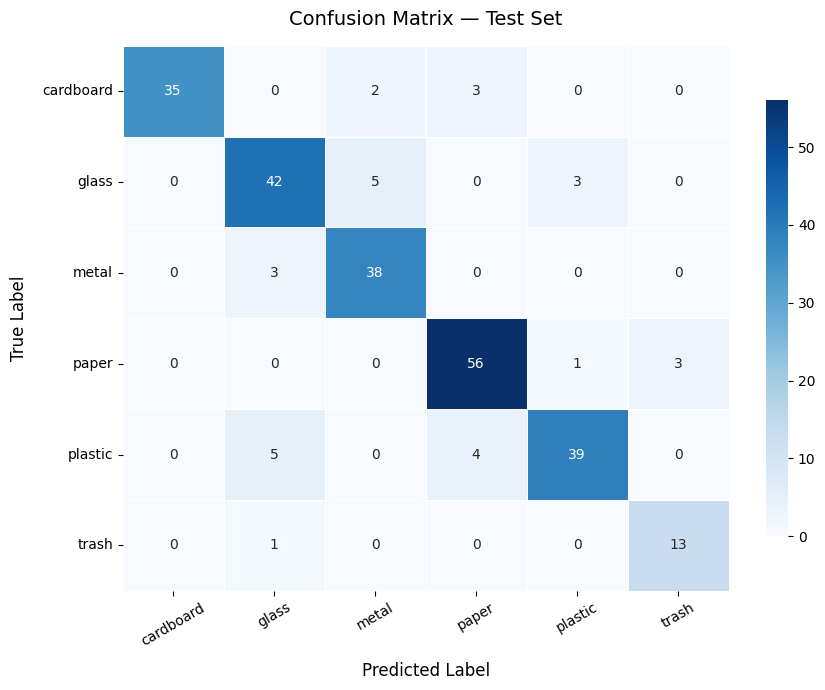

Saved: confusion_matrix.png


In [ ]:
# Confusion matrix shows:
# - Diagonal = correctly predicted (want these HIGH)
# - Off-diagonal = mistakes — which class was confused with which

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,           # show numbers inside cells
    fmt='d',              # integer format
    cmap='Blues',         # blue color scale
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Confusion Matrix — Test Set', fontsize=14, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_path = SAVE_DIR + "confusion_matrix.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: confusion_matrix.png")

In [ ]:
print("READING YOUR CONFUSION MATRIX:")
print("=" * 50)
print("Each ROW = actual class (what it really is)")
print("Each COL = predicted class (what model said)")
print("Diagonal = correct predictions")
print("=" * 50 + "\n")

for i, true_class in enumerate(CLASS_NAMES):
    correct   = cm[i, i]
    total     = cm[i].sum()
    accuracy  = correct / total * 100

    # Find which class it confused with most
    row = cm[i].copy()
    row[i] = 0   # ignore correct diagonal
    most_confused_idx = row.argmax()
    most_confused_n   = row[most_confused_idx]

    print(f"  {true_class:12s} → {correct:2d}/{total:2d} correct ({accuracy:.0f}%)", end="")
    if most_confused_n > 0:
        print(f"  | most confused with '{CLASS_NAMES[most_confused_idx]}' ({most_confused_n}x)")
    else:
        print("  | no confusion!")

READING YOUR CONFUSION MATRIX:
Each ROW = actual class (what it really is)
Each COL = predicted class (what model said)
Diagonal = correct predictions

  cardboard    → 35/40 correct (88%)  | most confused with 'paper' (3x)
  glass        → 42/50 correct (84%)  | most confused with 'metal' (5x)
  metal        → 38/41 correct (93%)  | most confused with 'glass' (3x)
  paper        → 56/60 correct (93%)  | most confused with 'trash' (3x)
  plastic      → 39/48 correct (81%)  | most confused with 'glass' (5x)
  trash        → 13/14 correct (93%)  | most confused with 'glass' (1x)


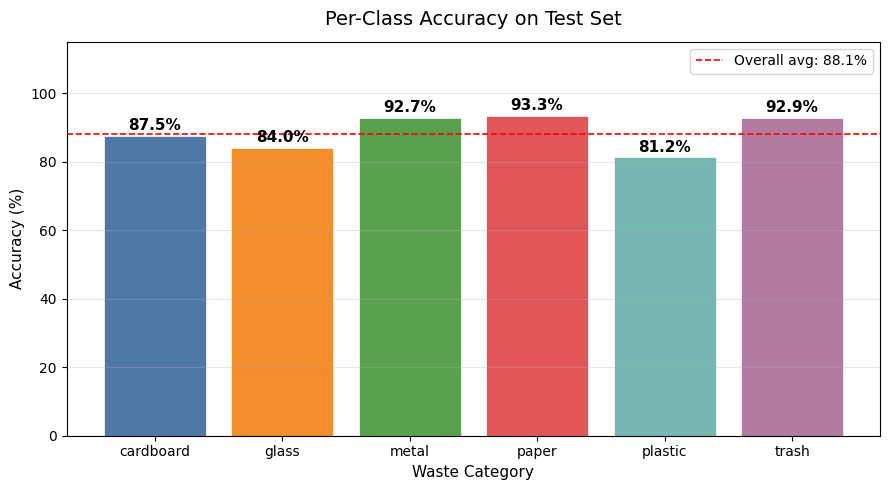

Saved: per_class_accuracy.png


In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2','#b07aa1']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors,
              edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# Draw a horizontal line at overall accuracy
ax.axhline(y=overall_acc*100, color='red', linestyle='--',
           linewidth=1.2, label=f'Overall avg: {overall_acc*100:.1f}%')

ax.set_title('Per-Class Accuracy on Test Set', fontsize=14, pad=12)
ax.set_xlabel('Waste Category', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = SAVE_DIR + "per_class_accuracy.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Saved: per_class_accuracy.png")

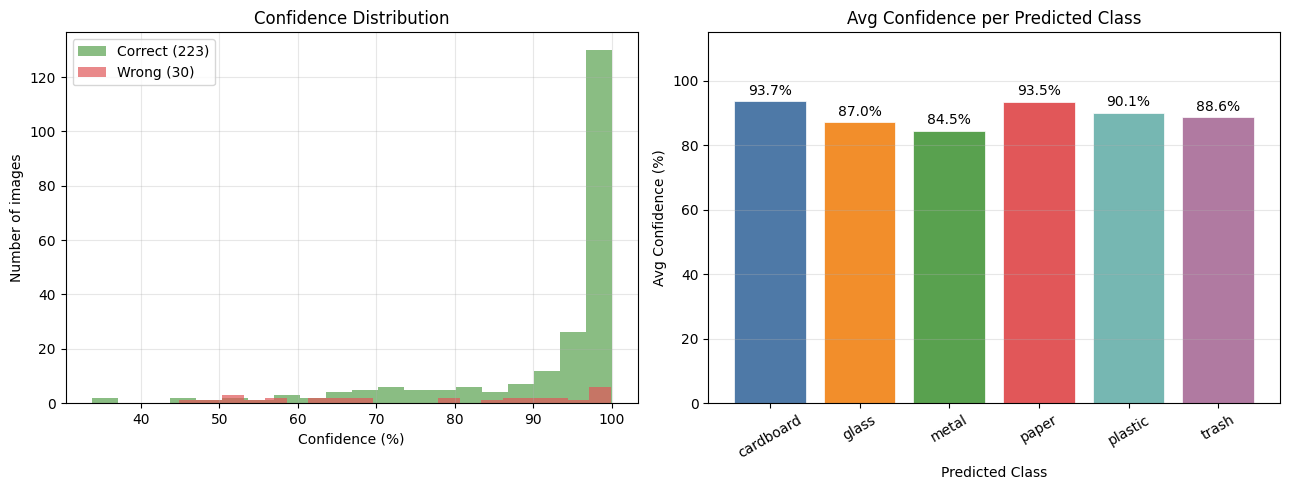

Saved: confidence_distribution.png


In [ ]:
# Get max confidence for each prediction
confidences = predictions.max(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram of confidence for correct vs wrong predictions
correct_mask = (y_pred == y_true)
axes[0].hist(confidences[correct_mask],  bins=20, alpha=0.7,
             color='#59a14f', label=f'Correct ({correct_mask.sum()})')
axes[0].hist(confidences[~correct_mask], bins=20, alpha=0.7,
             color='#e15759', label=f'Wrong ({(~correct_mask).sum()})')
axes[0].set_title('Confidence Distribution', fontsize=12)
axes[0].set_xlabel('Confidence (%)')
axes[0].set_ylabel('Number of images')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: average confidence per class
avg_conf_per_class = []
for i in range(NUM_CLASSES):
    mask = (y_pred == i)
    avg = confidences[mask].mean() if mask.sum() > 0 else 0
    avg_conf_per_class.append(avg)

colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2','#b07aa1']
axes[1].bar(CLASS_NAMES, avg_conf_per_class, color=colors,
            edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Confidence per Predicted Class', fontsize=12)
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Avg Confidence (%)')
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(axes[1].patches, avg_conf_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
save_path = SAVE_DIR + "confidence_distribution.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Saved: confidence_distribution.png")

Total wrong predictions: 30
Showing first 12 wrong predictions:



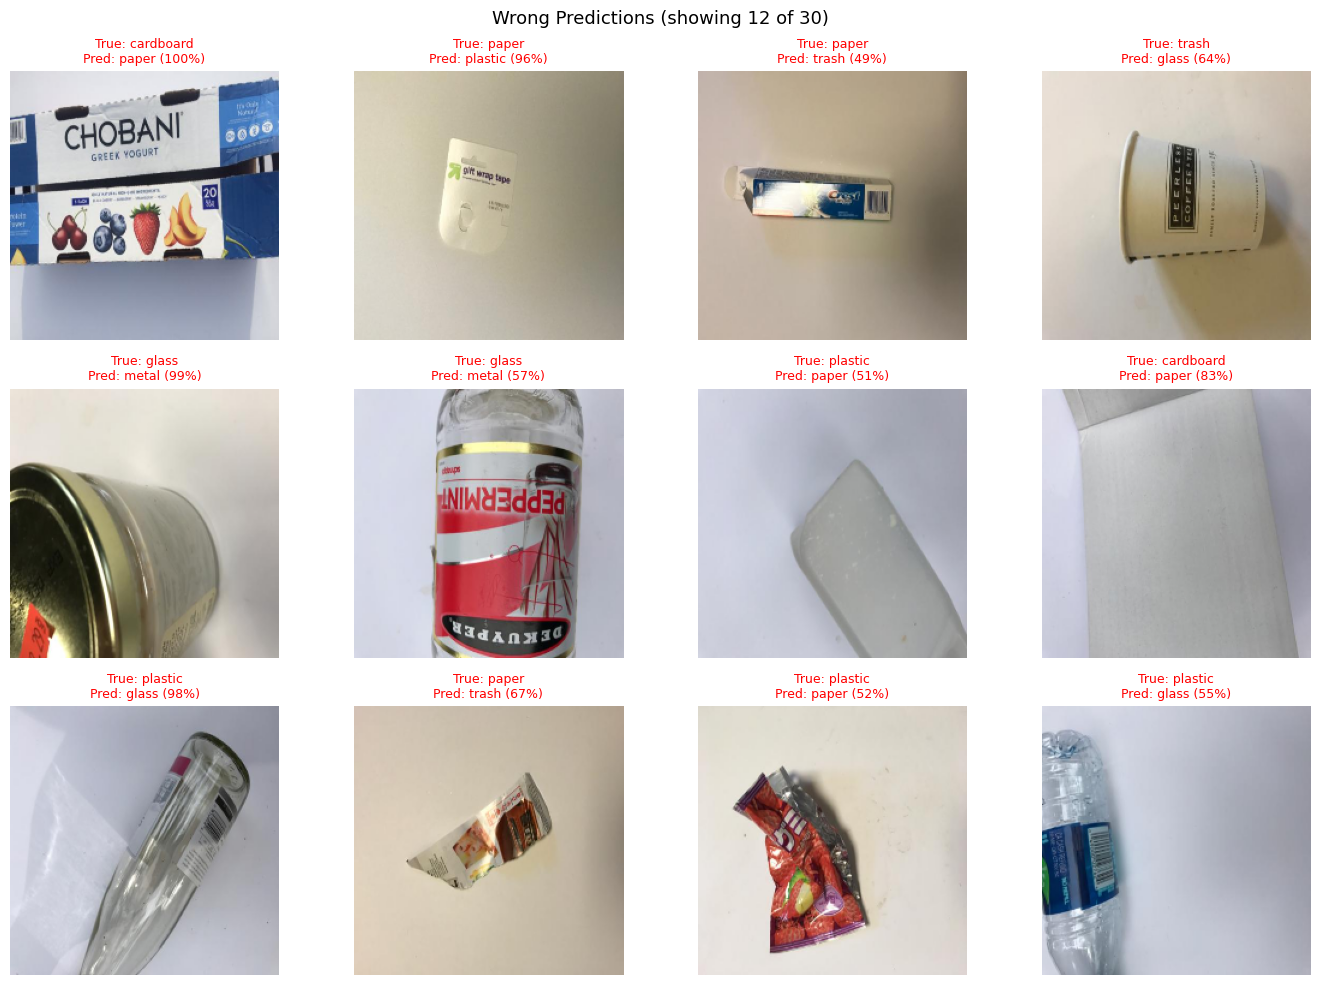

Saved: wrong_predictions.png


In [ ]:
# Display images the model got wrong — useful for intern report
wrong_indices = np.where(y_pred != y_true)[0]

print(f"Total wrong predictions: {len(wrong_indices)}")
print("Showing first 12 wrong predictions:\n")

# Show up to 12 wrong predictions
n_show = min(12, len(wrong_indices))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle(f'Wrong Predictions (showing {n_show} of {len(wrong_indices)})',
             fontsize=13)

for idx, ax in zip(wrong_indices[:n_show], axes.flat):
    img = X_test[idx].astype('uint8')   # convert for display
    true_label = CLASS_NAMES[y_true[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    conf       = predictions[idx][y_pred[idx]] * 100

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f'True: {true_label}\nPred: {pred_label} ({conf:.0f}%)',
        fontsize=9,
        color='red'
    )

# Hide unused subplots if fewer than 12 wrong
for ax in axes.flat[n_show:]:
    ax.axis('off')

plt.tight_layout()
save_path = SAVE_DIR + "wrong_predictions.png"
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: wrong_predictions.png")

In [ ]:
print("\n")
print("=" * 55)
print("  FINAL EVALUATION SUMMARY — waste_model_FINAL.keras")
print("=" * 55)
print(f"  Test set size      : {len(y_true)} images")
print(f"  Overall accuracy   : {overall_acc*100:.2f}%")
print(f"  Correct            : {(y_pred==y_true).sum()} images")
print(f"  Wrong              : {(y_pred!=y_true).sum()} images")
print(f"  Avg confidence     : {confidences.mean():.1f}%")
print("-" * 55)
print("  Per-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    total   = cm[i].sum()
    correct = cm[i, i]
    pct     = correct / total * 100
    bar     = "█" * int(pct / 5)
    print(f"    {name:12s}: {pct:5.1f}%  {bar}")
print("-" * 55)
print("  Files saved to Google Drive:")
for fname in ["confusion_matrix.png", "per_class_accuracy.png",
              "confidence_distribution.png", "wrong_predictions.png"]:
    print(f"    {fname}")
print("=" * 55)



  FINAL EVALUATION SUMMARY — waste_model_FINAL.keras
  Test set size      : 253 images
  Overall accuracy   : 88.14%
  Correct            : 223 images
  Wrong              : 30 images
  Avg confidence     : 89.8%
-------------------------------------------------------
  Per-class accuracy:
    cardboard   :  87.5%  █████████████████
    glass       :  84.0%  ████████████████
    metal       :  92.7%  ██████████████████
    paper       :  93.3%  ██████████████████
    plastic     :  81.2%  ████████████████
    trash       :  92.9%  ██████████████████
-------------------------------------------------------
  Files saved to Google Drive:
    confusion_matrix.png
    per_class_accuracy.png
    confidence_distribution.png
    wrong_predictions.png
